# Neural Networks From Scratch using NumPy
### With Adam Optimizer | FastAPI + Streamlit Ready | vs sklearn MLPClassifier

## 1. Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

## 2. Data Loading

In [9]:
def load_data(path):
    data = np.array(pd.read_csv(path))
    Y = data[:, 0].astype(int)
    X = data[:, 1:].T
    X = X / 255.0
    return X, Y

def load_test_data(path):
    data = np.array(pd.read_csv(path))
    X = data.T / 255.0
    return X

def train_val_split(X, Y, val_size=1000):
    X_val, Y_val = X[:, :val_size], Y[:val_size]
    X_train, Y_train = X[:, val_size:], Y[val_size:]
    return X_train, Y_train, X_val, Y_val

## 3. Activation Functions

In [10]:
def relu(Z):
    return np.maximum(0, Z)

def relu_deriv(Z):
    return Z > 0

def softmax(Z):
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)
    exp = np.exp(Z_stable)
    return exp / np.sum(exp, axis=0, keepdims=True)

def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

## 4. Parameter Initialization

In [11]:
def initialize_parameters(layers_dim):
    params = {}
    for l in range(1, len(layers_dim)):
        n_curr = layers_dim[l]
        n_prev = layers_dim[l-1]
        params[f'W{l}'] = np.random.randn(n_curr, n_prev) * np.sqrt(2.0 / n_prev)
        params[f'b{l}'] = np.zeros((n_curr, 1))
    return params

def initialize_adam(params):
    L = len(params) // 2
    v, s = {}, {}
    for l in range(1, L+1):
        v[f'dW{l}'] = np.zeros_like(params[f'W{l}'])
        v[f'db{l}'] = np.zeros_like(params[f'b{l}'])
        s[f'dW{l}'] = np.zeros_like(params[f'W{l}'])
        s[f'db{l}'] = np.zeros_like(params[f'b{l}'])
    return v, s

## 5. Forward Propagation

In [12]:
def forward_propagation(X, params):
    cache = {}
    L = len(params) // 2
    A = X

    for i in range(1, L):
        A_prev = A
        Z = params[f'W{i}'] @ A_prev + params[f'b{i}']
        A = relu(Z)
        cache[f'Z{i}'] = Z
        cache[f'A{i}'] = A

    ZL = params[f'W{L}'] @ A + params[f'b{L}']
    AL = softmax(ZL)
    cache[f'Z{L}'] = ZL
    cache[f'A{L}'] = AL

    return AL, cache

## 6. Loss & One-Hot

In [13]:
def compute_loss(AL, Y):
    m = Y.shape[0]
    loss = -1/m * np.sum(np.log(AL[Y.astype(int), range(m)] + 1e-8))
    return loss

def one_hot(Y, n_classes):
    m = Y.shape[0]
    Y_onehot = np.zeros((n_classes, m))
    Y_onehot[Y.astype(int), range(m)] = 1
    return Y_onehot

## 7. Backward Propagation

In [14]:
def backward_propagation(AL, Y, params, cache, X):
    grads = {}
    m = Y.shape[0]
    L = len(params) // 2

    Y_onehot = one_hot(Y, AL.shape[0])

    dZ = AL - Y_onehot
    grads[f'dW{L}'] = 1/m * dZ @ cache[f'A{L-1}'].T
    grads[f'db{L}'] = 1/m * np.sum(dZ, axis=1, keepdims=True)

    for l in range(L-1, 0, -1):
        dA = params[f'W{l+1}'].T @ dZ
        dZ = dA * relu_deriv(cache[f'Z{l}'])
        A_prev = cache[f'A{l-1}'] if l > 1 else X
        grads[f'dW{l}'] = 1/m * dZ @ A_prev.T
        grads[f'db{l}'] = 1/m * np.sum(dZ, axis=1, keepdims=True)

    return grads

## 8. Optimizers

In [15]:
def update_parameters_sgd(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L+1):
        params[f'W{l}'] -= learning_rate * grads[f'dW{l}']
        params[f'b{l}'] -= learning_rate * grads[f'db{l}']
    return params

def update_parameters_adam(params, grads, v, s, t, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    L = len(params) // 2
    for l in range(1, L+1):
        v[f'dW{l}'] = beta1 * v[f'dW{l}'] + (1 - beta1) * grads[f'dW{l}']
        v[f'db{l}'] = beta1 * v[f'db{l}'] + (1 - beta1) * grads[f'db{l}']

        s[f'dW{l}'] = beta2 * s[f'dW{l}'] + (1 - beta2) * grads[f'dW{l}']**2
        s[f'db{l}'] = beta2 * s[f'db{l}'] + (1 - beta2) * grads[f'db{l}']**2

        v_corrected_W = v[f'dW{l}'] / (1 - beta1**t)
        v_corrected_b = v[f'db{l}'] / (1 - beta1**t)
        s_corrected_W = s[f'dW{l}'] / (1 - beta2**t)
        s_corrected_b = s[f'db{l}'] / (1 - beta2**t)

        params[f'W{l}'] -= learning_rate * v_corrected_W / (np.sqrt(s_corrected_W) + epsilon)
        params[f'b{l}'] -= learning_rate * v_corrected_b / (np.sqrt(s_corrected_b) + epsilon)

    return params, v, s

## 9. Predict & Accuracy

In [16]:
def predict(X, params):
    AL, _ = forward_propagation(X, params)
    return np.argmax(AL, axis=0)

def predict_proba(X, params):
    AL, _ = forward_propagation(X, params)
    return AL

def accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.shape[0] * 100

## 10. Training

In [17]:
def train(X, Y, layers_dim, optimizer='adam', learning_rate=0.001, epochs=500, X_val=None, Y_val=None):
    params = initialize_parameters(layers_dim)
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    if optimizer == 'adam':
        v, s = initialize_adam(params)

    for i in range(1, epochs+1):
        AL, cache = forward_propagation(X, params)
        loss = compute_loss(AL, Y)
        grads = backward_propagation(AL, Y, params, cache, X)

        if optimizer == 'adam':
            params, v, s = update_parameters_adam(params, grads, v, s, t=i, learning_rate=learning_rate)
        else:
            params = update_parameters_sgd(params, grads, learning_rate)

        if i % 50 == 0:
            preds = predict(X, params)
            train_acc = accuracy(preds, Y)
            history['train_loss'].append(loss)
            history['train_acc'].append(train_acc)

            if X_val is not None:
                val_preds = predict(X_val, params)
                val_acc = accuracy(val_preds, Y_val)
                history['val_acc'].append(val_acc)
                print(f"Epoch {i} | Loss: {loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
            else:
                print(f"Epoch {i} | Loss: {loss:.4f} | Train Acc: {train_acc:.2f}%")

    return params, history

## 11. Save & Load Model

In [18]:
def save_model(params, layers_dim, path='model.pkl'):
    model_data = {'params': params, 'layers_dim': layers_dim}
    with open(path, 'wb') as f:
        pickle.dump(model_data, f)
    print(f"Model saved to {path}")

def load_model(path='model.pkl'):
    with open(path, 'rb') as f:
        model_data = pickle.load(f)
    return model_data['params'], model_data['layers_dim']

def predict_single(image_array, params):
    x = np.array(image_array).reshape(-1, 1) / 255.0
    AL, _ = forward_propagation(x, params)
    predicted_class = int(np.argmax(AL, axis=0)[0])
    confidence = float(np.max(AL))
    all_probs = AL.flatten().tolist()
    return {
        'prediction': predicted_class,
        'confidence': round(confidence * 100, 2),
        'probabilities': {str(i): round(p * 100, 2) for i, p in enumerate(all_probs)}
    }

## 12. Run on MNIST

In [19]:
X, Y = load_data('train.csv')
X_train, Y_train, X_val, Y_val = train_val_split(X, Y, val_size=1000)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

LAYERS = [784, 128, 64, 10]

start = time.time()
params, history_adam = train(X_train, Y_train, LAYERS, optimizer='adam', learning_rate=0.001, epochs=500, X_val=X_val, Y_val=Y_val)
adam_time = time.time() - start
adam_preds = predict(X_val, params)
adam_acc = accuracy(adam_preds, Y_val)
scratch_acc = adam_acc
val_preds = adam_preds
print(f"Adam — Val Acc: {adam_acc:.2f}% | Time: {adam_time:.2f}s")

start = time.time()
params_sgd, history_sgd = train(X_train, Y_train, LAYERS, optimizer='sgd', learning_rate=0.1, epochs=500, X_val=X_val, Y_val=Y_val)
sgd_time = time.time() - start
sgd_preds = predict(X_val, params_sgd)
sgd_acc = accuracy(sgd_preds, Y_val)
print(f"SGD  — Val Acc: {sgd_acc:.2f}% | Time: {sgd_time:.2f}s")

save_model(params, LAYERS)

Train: (784, 41000) | Val: (784, 1000)
Epoch 50 | Loss: 0.2845 | Train Acc: 91.99% | Val Acc: 91.70%
Epoch 100 | Loss: 0.1742 | Train Acc: 95.09% | Val Acc: 94.80%
Epoch 150 | Loss: 0.1194 | Train Acc: 96.68% | Val Acc: 95.70%
Epoch 200 | Loss: 0.0831 | Train Acc: 97.75% | Val Acc: 96.00%
Epoch 250 | Loss: 0.0578 | Train Acc: 98.50% | Val Acc: 96.20%
Epoch 300 | Loss: 0.0405 | Train Acc: 99.06% | Val Acc: 97.00%
Epoch 350 | Loss: 0.0283 | Train Acc: 99.39% | Val Acc: 97.20%
Epoch 400 | Loss: 0.0197 | Train Acc: 99.67% | Val Acc: 97.20%
Epoch 450 | Loss: 0.0139 | Train Acc: 99.85% | Val Acc: 97.30%
Epoch 500 | Loss: 0.0099 | Train Acc: 99.94% | Val Acc: 97.30%
Adam — Val Acc: 97.30% | Time: 264.02s
Epoch 50 | Loss: 0.5667 | Train Acc: 85.28% | Val Acc: 85.80%
Epoch 100 | Loss: 0.3917 | Train Acc: 89.02% | Val Acc: 89.70%
Epoch 150 | Loss: 0.3327 | Train Acc: 90.49% | Val Acc: 90.50%
Epoch 200 | Loss: 0.2988 | Train Acc: 91.37% | Val Acc: 91.00%
Epoch 250 | Loss: 0.2748 | Train Acc: 92.0

## 13. Comparison b/w Scratch NN vs sklearn MLPClassifier vs Keras

In [20]:
X_train_sk = X_train.T
X_val_sk = X_val.T

start = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)
mlp.fit(X_train_sk, Y_train)
sklearn_time = time.time() - start
sklearn_preds = mlp.predict(X_val_sk)
sklearn_acc = accuracy_score(Y_val, sklearn_preds) * 100

import keras

import keras

keras_model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
keras_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
start = time.time()
keras_model.fit(X_train_sk, Y_train, epochs=50, batch_size=32, validation_data=(X_val_sk, Y_val), verbose=0)
keras_time = time.time() - start
keras_preds = np.argmax(keras_model.predict(X_val_sk, verbose=0), axis=1)
keras_acc = accuracy_score(Y_val, keras_preds) * 100

print("=" * 65)
print(f"{'Metric':<25} {'Scratch':>10} {'sklearn':>10} {'Keras':>10}")
print("=" * 65)
print(f"{'Val Accuracy (%)':<25} {scratch_acc:>10.2f} {sklearn_acc:>10.2f} {keras_acc:>10.2f}")
print(f"{'Training Time (s)':<25} {adam_time:>10.2f} {sklearn_time:>10.2f} {keras_time:>10.2f}")
print("=" * 65)

Metric                       Scratch    sklearn      Keras
Val Accuracy (%)               97.30      98.40      98.00
Training Time (s)             264.02      73.09     203.05


## 14. Plots

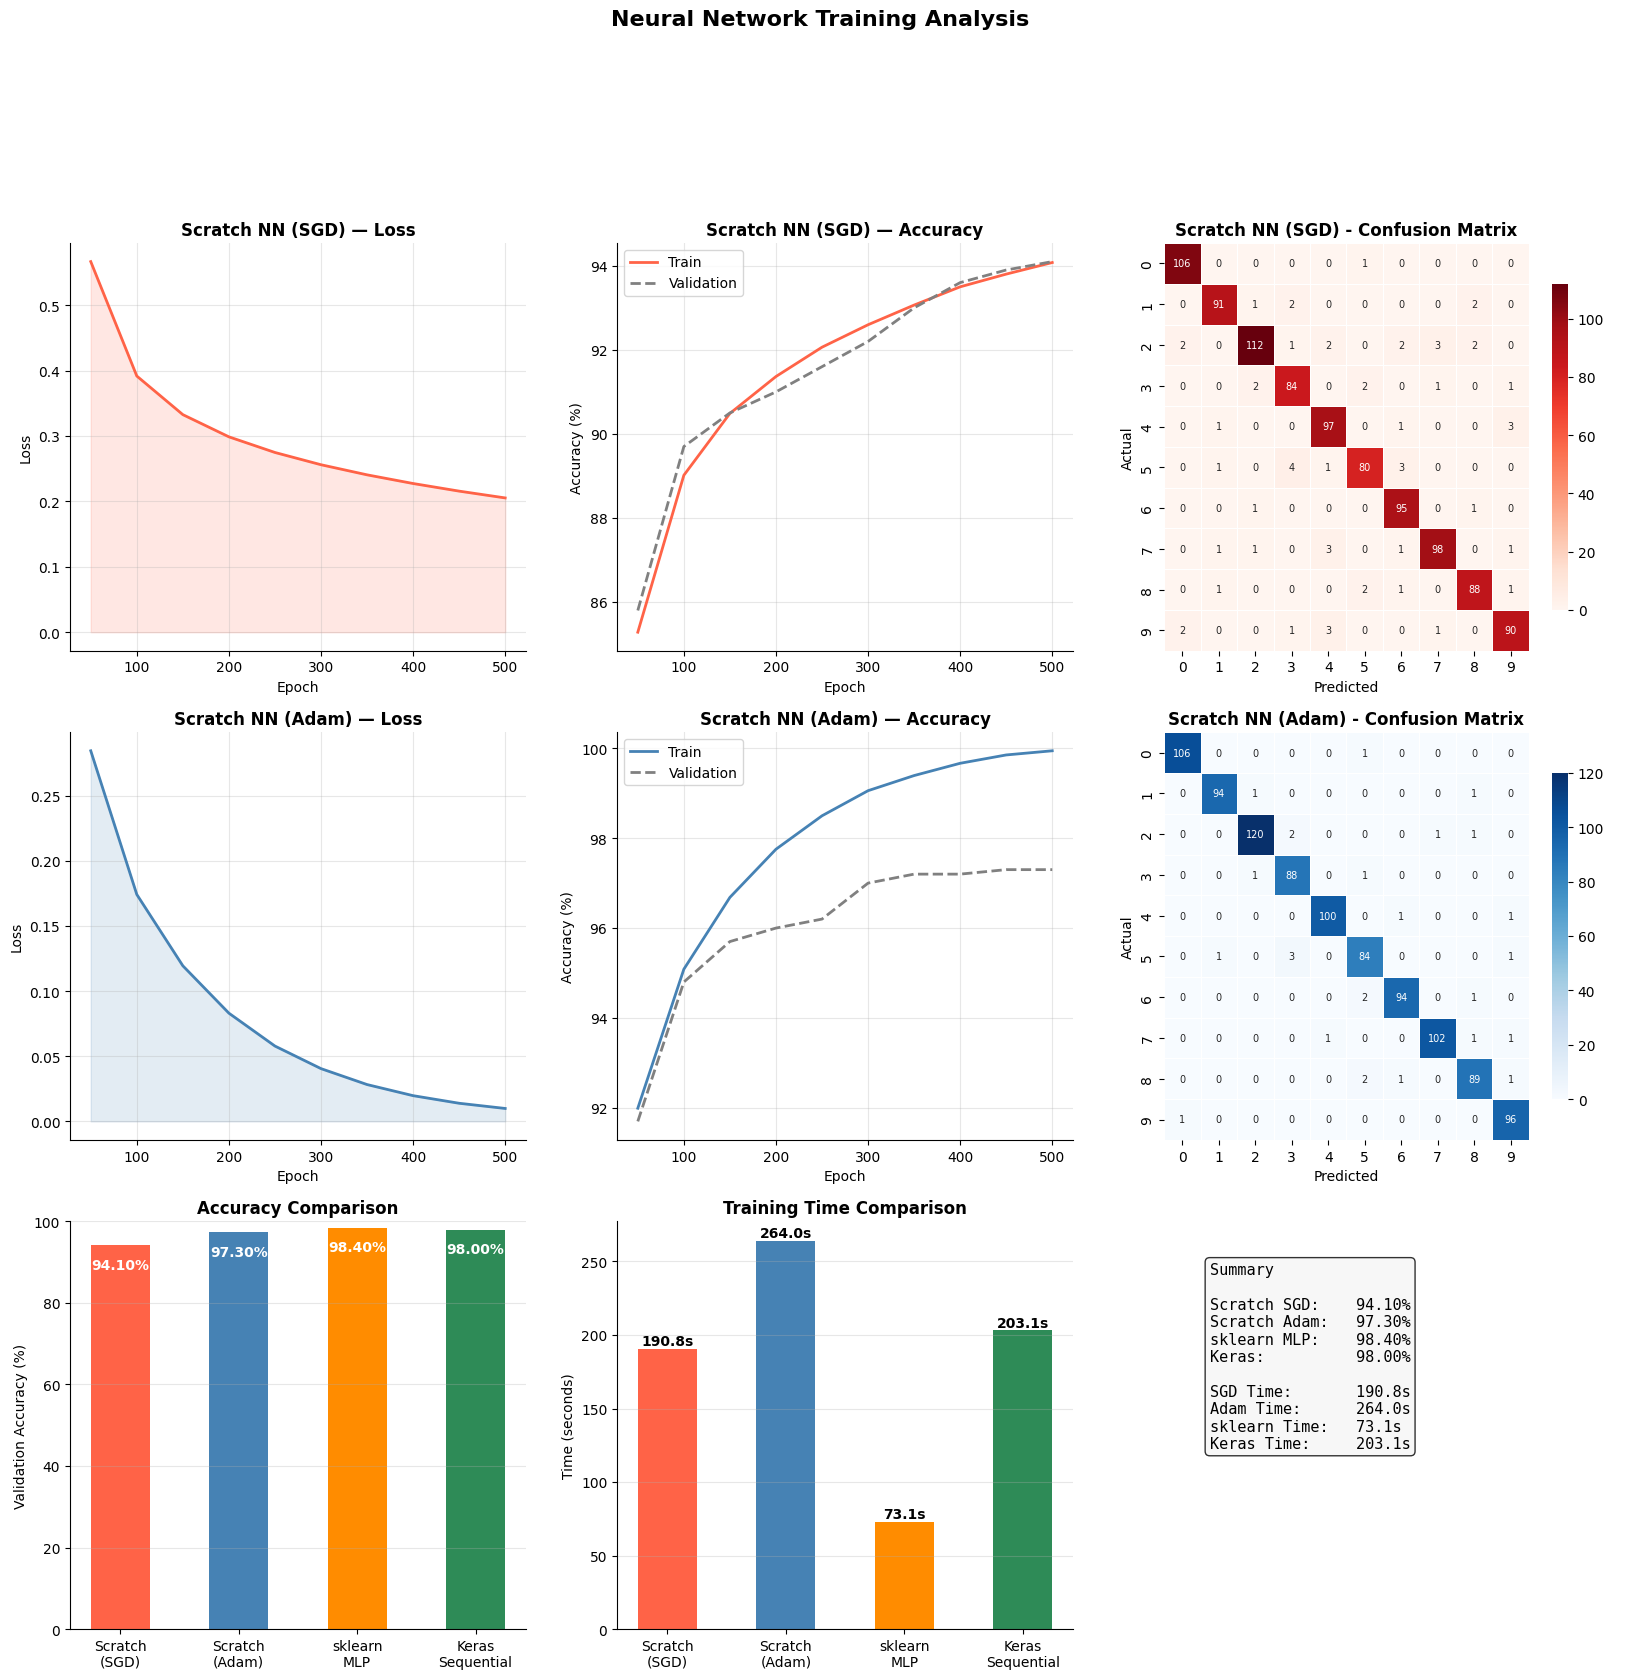

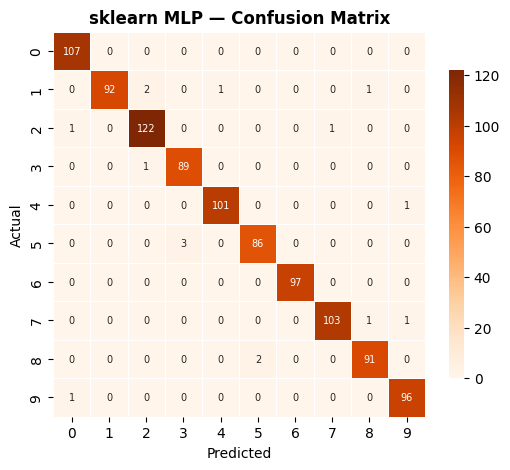

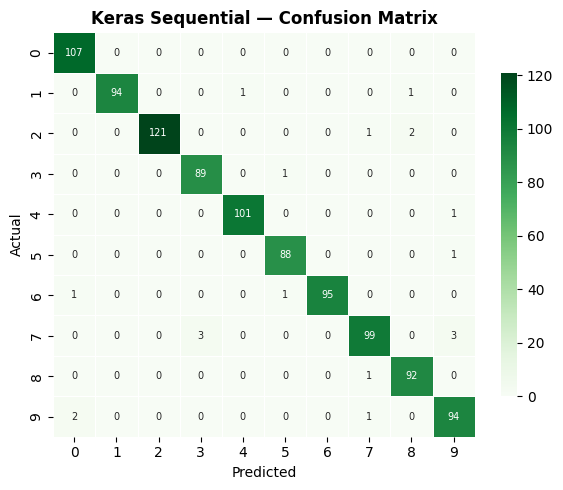


  Classification Report — Scratch SGD
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.96      0.95      0.95        96
           2       0.96      0.90      0.93       124
           3       0.91      0.93      0.92        90
           4       0.92      0.95      0.93       102
           5       0.94      0.90      0.92        89
           6       0.92      0.98      0.95        97
           7       0.95      0.93      0.94       105
           8       0.95      0.95      0.95        93
           9       0.94      0.93      0.93        97

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000


  Classification Report — Scratch Adam
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       107
           1       0.99      0.98      0.98        96

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('Neural Network Training Analysis', fontsize=16, fontweight='bold', y=1.01)

epochs_axis = [i * 50 for i in range(1, len(history_sgd['train_loss'])+1)]

model_histories = [
    (history_sgd, 'Scratch NN (SGD)', 'tomato', 'salmon'),
    (history_adam, 'Scratch NN (Adam)', 'steelblue', 'lightblue'),
]

row_labels = ['Scratch NN (SGD)', 'Scratch NN (Adam)', 'All Models']

for row, (history, label, color, fill_color) in enumerate(model_histories):
    axes[row][0].plot(epochs_axis, history['train_loss'], color=color, linewidth=2)
    axes[row][0].fill_between(epochs_axis, history['train_loss'], alpha=0.15, color=color)
    axes[row][0].set_title(f'{label} — Loss', fontsize=12, fontweight='bold')
    axes[row][0].set_xlabel('Epoch')
    axes[row][0].set_ylabel('Loss')
    axes[row][0].grid(True, alpha=0.3)
    axes[row][0].spines['top'].set_visible(False)
    axes[row][0].spines['right'].set_visible(False)

    axes[row][1].plot(epochs_axis, history['train_acc'], label='Train', color=color, linewidth=2)
    if history['val_acc']:
        axes[row][1].plot(epochs_axis, history['val_acc'], label='Validation', color='gray', linewidth=2, linestyle='--')
    axes[row][1].set_title(f'{label} — Accuracy', fontsize=12, fontweight='bold')
    axes[row][1].set_xlabel('Epoch')
    axes[row][1].set_ylabel('Accuracy (%)')
    axes[row][1].legend()
    axes[row][1].grid(True, alpha=0.3)
    axes[row][1].spines['top'].set_visible(False)
    axes[row][1].spines['right'].set_visible(False)

    cm = confusion_matrix(Y_val, sgd_preds if row == 0 else adam_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if row == 1 else 'Reds',
                ax=axes[row][2], linewidths=0.5, linecolor='white',
                annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
    axes[row][2].set_title(f'{label} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[row][2].set_xlabel('Predicted')
    axes[row][2].set_ylabel('Actual')

models = ['Scratch\n(SGD)', 'Scratch\n(Adam)', 'sklearn\nMLP', 'Keras\nSequential']
accs = [sgd_acc, adam_acc, sklearn_acc, keras_acc]
colors = ['tomato', 'steelblue', 'darkorange', 'seagreen']
bars = axes[2][0].bar(models, accs, color=colors, width=0.5)
for bar, acc in zip(bars, accs):
    axes[2][0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
                    f'{acc:.2f}%', ha='center', va='top', color='white', fontweight='bold', fontsize=10)
axes[2][0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[2][0].set_ylabel('Validation Accuracy (%)')
axes[2][0].set_ylim([0, 100])
axes[2][0].grid(True, alpha=0.3, axis='y')
axes[2][0].spines['top'].set_visible(False)
axes[2][0].spines['right'].set_visible(False)

times = [sgd_time, adam_time, sklearn_time, keras_time]
bars2 = axes[2][1].bar(models, times, color=colors, width=0.5)
for bar, t in zip(bars2, times):
    axes[2][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{t:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[2][1].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[2][1].set_ylabel('Time (seconds)')
axes[2][1].grid(True, alpha=0.3, axis='y')
axes[2][1].spines['top'].set_visible(False)
axes[2][1].spines['right'].set_visible(False)

cms_all = [confusion_matrix(Y_val, sklearn_preds), confusion_matrix(Y_val, keras_preds)]
titles_all = ['sklearn MLP', 'Keras Sequential']
cmaps_all = ['Oranges', 'Greens']

for cm, title, cmap in zip(cms_all, titles_all, cmaps_all):
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax2,
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
    ax2.set_title(f'{title} — Confusion Matrix', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')

axes[2][2].axis('off')
summary_text = (
    f"Summary\n\n"
    f"Scratch SGD:    {sgd_acc:.2f}%\n"
    f"Scratch Adam:   {adam_acc:.2f}%\n"
    f"sklearn MLP:    {sklearn_acc:.2f}%\n"
    f"Keras:          {keras_acc:.2f}%\n\n"
    f"SGD Time:       {sgd_time:.1f}s\n"
    f"Adam Time:      {adam_time:.1f}s\n"
    f"sklearn Time:   {sklearn_time:.1f}s\n"
    f"Keras Time:     {keras_time:.1f}s"
)
axes[2][2].text(0.1, 0.9, summary_text, transform=axes[2][2].transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8))

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

for title, preds in [('Scratch SGD', sgd_preds), ('Scratch Adam', adam_preds),
                     ('sklearn MLP', sklearn_preds), ('Keras Sequential', keras_preds)]:
    print(f"\n{'=' * 55}")
    print(f"  Classification Report — {title}")
    print(f"{'=' * 55}")
    print(classification_report(Y_val, preds))

In [22]:
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

results = {
    "accuracies": {
        "Scratch SGD":  round(float(sgd_acc), 4),
        "Scratch Adam": round(float(adam_acc), 4),
        "sklearn MLP":  round(float(sklearn_acc), 4),
        "Keras":        round(float(keras_acc), 4),
    },
    "times": {
        "Scratch SGD":  round(float(sgd_time), 2),
        "Scratch Adam": round(float(adam_time), 2),
        "sklearn MLP":  round(float(sklearn_time), 2),
        "Keras":        round(float(keras_time), 2),
    },
    "history_adam": {
        "train_loss": [round(float(x), 6) for x in history_adam["train_loss"]],
        "train_acc":  [round(float(x), 4) for x in history_adam["train_acc"]],
        "val_acc":    [round(float(x), 4) for x in history_adam["val_acc"]],
    },
    "history_sgd": {
        "train_loss": [round(float(x), 6) for x in history_sgd["train_loss"]],
        "train_acc":  [round(float(x), 4) for x in history_sgd["train_acc"]],
        "val_acc":    [round(float(x), 4) for x in history_sgd["val_acc"]],
    },
    "confusion_matrices": {
        "Scratch SGD":  confusion_matrix(Y_val, sgd_preds).tolist(),
        "Scratch Adam": confusion_matrix(Y_val, adam_preds).tolist(),
        "sklearn MLP":  confusion_matrix(Y_val, sklearn_preds).tolist(),
        "Keras":        confusion_matrix(Y_val, keras_preds).tolist(),
    },
    "classification_reports": {
        "Scratch SGD":  classification_report(Y_val, sgd_preds, output_dict=True),
        "Scratch Adam": classification_report(Y_val, adam_preds, output_dict=True),
        "sklearn MLP":  classification_report(Y_val, sklearn_preds, output_dict=True),
        "Keras":        classification_report(Y_val, keras_preds, output_dict=True),
    },
    "epochs": list(range(50, 500 + 1, 50)),
    "layers": LAYERS,
    "val_size": 1000,
    "train_size": int(X_train.shape[1]),
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results.json")
print(f"  Models: {list(results['accuracies'].keys())}")
print(f"  Best:   {max(results['accuracies'], key=results['accuracies'].get)} @ {max(results['accuracies'].values()):.2f}%")

Saved results.json
  Models: ['Scratch SGD', 'Scratch Adam', 'sklearn MLP', 'Keras']
  Best:   sklearn MLP @ 98.40%
